In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

In [3]:
import string
import pandas as pd
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")

In [ ]:
df=pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")
df.head()

In [5]:
df=pd.read_csv("questions.csv")

In [6]:
df1 = copy.deepcopy(df)

In [7]:
df1.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [12]:
df1

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [14]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


# BOW

In [56]:
new_df = df1.sample(90000)
new_df=new_df.dropna()

In [58]:
ques_df =new_df[['question1','question2']]
ques_df.head()

,question1,question2
41572,How can I learn programming for free?,How do I learn programming for free?
10517,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...
299627,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?
218618,How do you turn off your Furby?,Are Furbys considered examples of AI?
21881,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?


In [60]:
ques_df=ques_df.dropna()

In [62]:
# Import CountVectorizer to convert text into numerical feature vectors
from sklearn.feature_extraction.text import CountVectorizer

# Combine question1 and question2 into a single list
# This ensures the same vocabulary is learned from both columns
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Create a Bag-of-Words vectorizer
# Keep only the top 3000 most frequent words
cv = CountVectorizer(max_features=3000)

# Learn the vocabulary and transform all questions into vectors
# Shape after transformation:
# (number_of_questions * 2, 3000)
#
# np.vsplit(..., 2) splits the matrix into two equal parts:
# q1_arr -> vectors for question1
# q2_arr -> vectors for question2
q1_arr, q2_arr = np.vsplit(
    cv.fit_transform(questions).toarray(),
    2
)

# Convert question1 vectors into a DataFrame
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)

# Convert question2 vectors into a DataFrame
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)

# Concatenate both question representations side-by-side
# Final shape becomes:
# (30000, 6000)
# 3000 features from question1 + 3000 features from question2 = 6000
# 30000 Row data  
temp_df = pd.concat([temp_df1, temp_df2], axis=1)

# Display shape of the final feature matrix
temp_df.shape

(89999, 6000)

In [63]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
41572,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10517,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
299627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
218618,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21881,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111752,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
361137,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
120287,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
307127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
temp_df['is_duplicate'] = df1['is_duplicate']

In [176]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7731666666666667

In [178]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7338888888888889

-----

----

In [2]:
# We already have 6000 Bag-of-Words features
# (3000 features from Question 1 + 3000 features from Question 2).
#
# Now we are augmenting the feature set with 7 handcrafted features:
# 1. q1_len      -> Character length of Question 1
# 2. q2_len      -> Character length of Question 2
# 3. q1_words    -> Number of words in Question 1
# 4. q2_words    -> Number of words in Question 2
# 5. word_common -> Number of common unique words between Q1 and Q2
# 6. word_total  -> Total number of words in Q1 and Q2
# 7. word_share  -> word_common / word_total
#
# Final feature dimension:
# 6000 (BoW features) + 7 (engineered features) = 6007 features

###  Feature Engineering

In [69]:
#1. q1_len      -> Character length of Question 1
new_df["q1_len"]=new_df["question1"].str.len()

# 2. q2_len      -> Character length of Question 2
new_df["q2_len"]=new_df["question2"].str.len()

In [71]:
new_df

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
41572,41572,82801,82802,How can I learn programming for free?,How do I learn programming for free?,1,37,36
10517,10517,21001,21002,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...,0,40,52
299627,299627,588497,588498,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?,0,89,46
218618,218618,431025,431026,How do you turn off your Furby?,Are Furbys considered examples of AI?,0,31,37
21881,21881,43655,43656,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?,0,69,48
...,...,...,...,...,...,...,...,...
111752,111752,221584,221585,Can I carry a Zippo lighter in flight?,Are there any quality classifications or types...,0,38,91
361137,361137,707085,707086,What are the best stairbuilder companies in Qu...,"Who are the best stairbuilders in Queensland, ...",1,66,56
120287,120287,238380,238381,How can I make a plan to lose 12-15 pounds in ...,How can I lose 12-15 pounds in 3 months?,1,57,40
307127,307127,602976,602977,Is Benadryl safe for consumption by dogs?,How does Benadryl affect dogs?,1,41,30


In [73]:
# 3. q1_words    -> Number of words in Question 1

new_df['q1_num_words']= new_df["question1"].str.split().apply(lambda x : len(x))

In [74]:
# 4. q2_words    -> Number of words in Question 2

In [77]:
new_df['q2_num_words']= new_df['question2'].apply(lambda row: len(row.split(" ")))

In [79]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
41572,41572,82801,82802,How can I learn programming for free?,How do I learn programming for free?,1,37,36,7,7
10517,10517,21001,21002,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...,0,40,52,7,8
299627,299627,588497,588498,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?,0,89,46,15,8
218618,218618,431025,431026,How do you turn off your Furby?,Are Furbys considered examples of AI?,0,31,37,7,6
21881,21881,43655,43656,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?,0,69,48,11,9


In [81]:
# 5. word_common -> Number of common unique words between Q1 and Q2

In [83]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [85]:
new_df['word_common'] = new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
41572,41572,82801,82802,How can I learn programming for free?,How do I learn programming for free?,1,37,36,7,7,6
10517,10517,21001,21002,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...,0,40,52,7,8,5
299627,299627,588497,588498,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?,0,89,46,15,8,5
218618,218618,431025,431026,How do you turn off your Furby?,Are Furbys considered examples of AI?,0,31,37,7,6,0
21881,21881,43655,43656,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?,0,69,48,11,9,2


In [86]:
# 6. word_total  -> Total number of unique words in Q1 and Q2

In [87]:
def unique_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return (len(w1) + len(w2))

In [88]:
new_df['unique_words_total'] = new_df.apply(unique_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,unique_words_total
41572,41572,82801,82802,How can I learn programming for free?,How do I learn programming for free?,1,37,36,7,7,6,14
10517,10517,21001,21002,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...,0,40,52,7,8,5,15
299627,299627,588497,588498,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?,0,89,46,15,8,5,20
218618,218618,431025,431026,How do you turn off your Furby?,Are Furbys considered examples of AI?,0,31,37,7,6,0,13
21881,21881,43655,43656,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?,0,69,48,11,9,2,19


In [89]:
# 7. word_share  -> word_common / word_total

In [90]:
new_df['word_share'] = round(new_df['word_common']/new_df['unique_words_total'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,unique_words_total,word_share
41572,41572,82801,82802,How can I learn programming for free?,How do I learn programming for free?,1,37,36,7,7,6,14,0.43
10517,10517,21001,21002,What is the voltage divider bias method?,Electronics: What is a voltage divider bias ci...,0,40,52,7,8,5,15,0.33
299627,299627,588497,588498,Is Java a compiled language or interpreted? Wh...,What language is the Java compiler written in?,0,89,46,15,8,5,20,0.25
218618,218618,431025,431026,How do you turn off your Furby?,Are Furbys considered examples of AI?,0,31,37,7,6,0,13,0.00
21881,21881,43655,43656,Uber (company): What does the organizational c...,How much does Uber charge passengers for a ride?,0,69,48,11,9,2,19,0.11


minimum characters 1
maximum characters 345
average num of characters 59


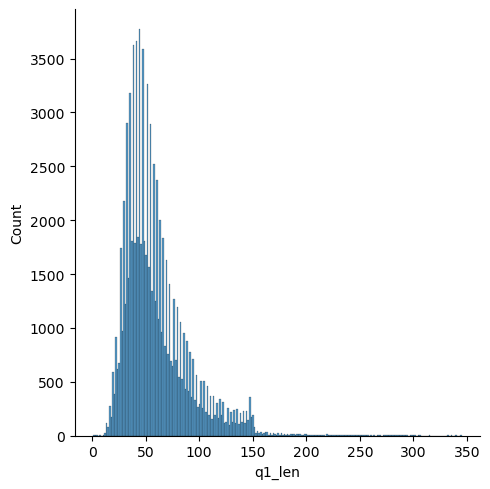

In [91]:
# Analysis of features
sns.displot(new_df['q1_len'])
print('minimum characters',new_df['q1_len'].min())
print('maximum characters',new_df['q1_len'].max())
print('average num of characters',int(new_df['q1_len'].mean()))

In [95]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'unique_words_total', 'word_share'],
      dtype='object')

In [96]:
l=['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'word_common',
       'unique_words_total', 'word_share']

minimum characters 1
maximum characters 345
average num of characters 59
******************************
minimum characters 2
maximum characters 1169
average num of characters 60
******************************
minimum characters 1
maximum characters 73
average num of characters 10
******************************
minimum characters 1
maximum characters 237
average num of characters 11
******************************
minimum characters 0
maximum characters 33
average num of characters 4
******************************
minimum characters 5
maximum characters 164
average num of characters 21
******************************
minimum characters 0.0
maximum characters 0.5
average num of characters 0
******************************


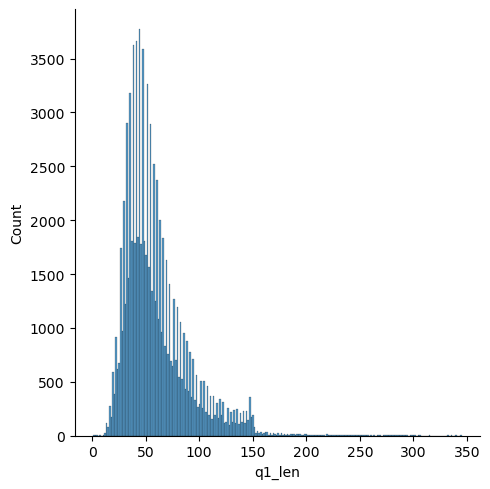

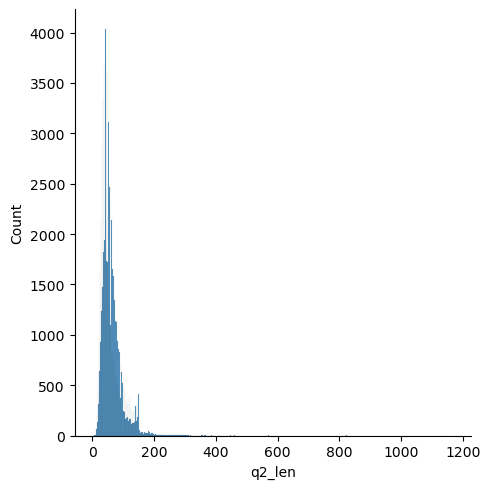

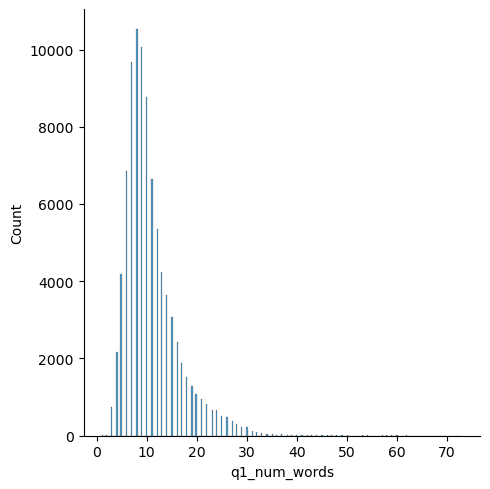

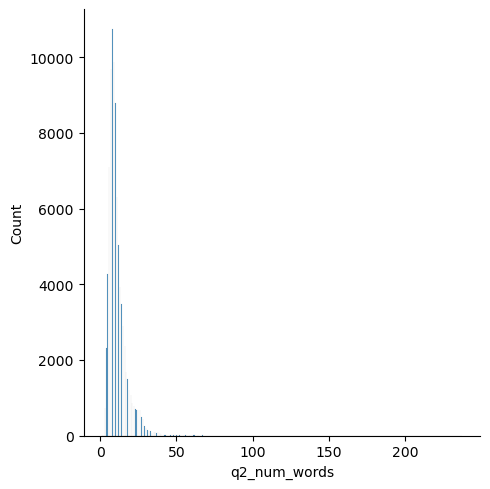

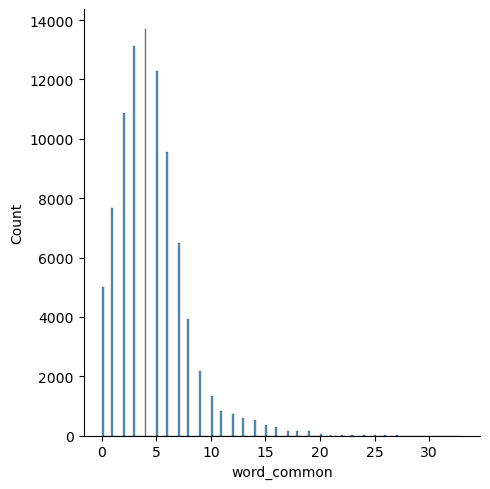

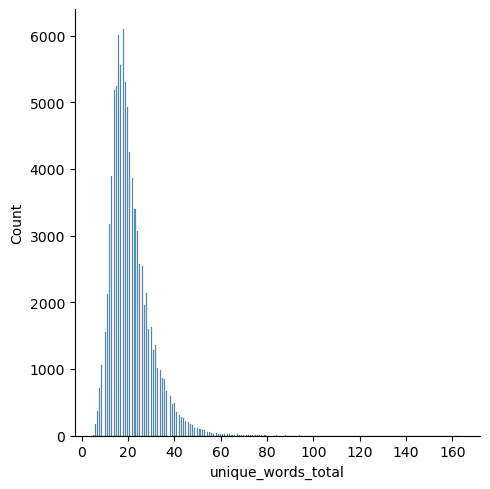

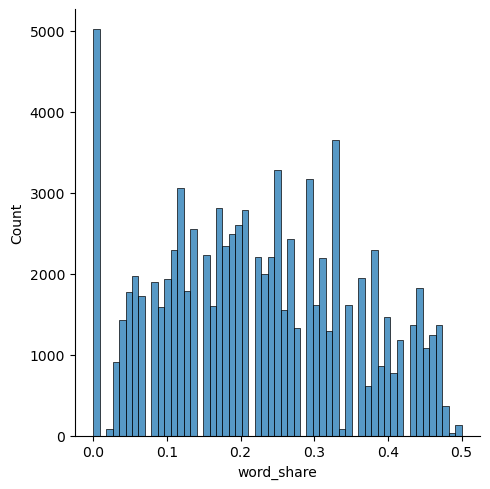

In [97]:
for i in l:
    sns.displot(new_df[i])
    print('minimum characters',new_df[i].min())
    print('maximum characters',new_df[i].max())
    print('average num of characters',int(new_df[i].mean()))

    print("******************************")

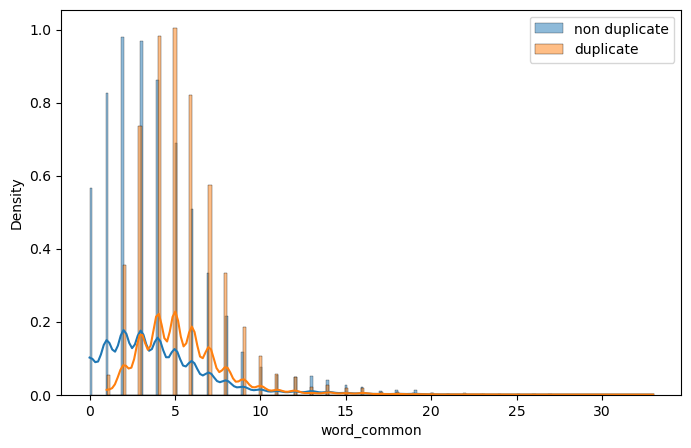

In [111]:
# common words
plt.figure(figsize=(8,5))

sns.histplot(
    new_df[new_df['is_duplicate']==0]['word_common'],
    label='non duplicate',
    kde=True,
    stat='density'
)

sns.histplot(
    new_df[new_df['is_duplicate']==1]['word_common'],
    label='duplicate',
    kde=True,
    stat='density'
)

plt.legend()
plt.show()